# Toy DAG demo

Four `Source` artifacts (real Project Gutenberg texts) feeding a `Tokenizer`
trained on all of them, then a `TokenizedSource` for `odyssey`. The tokenizer
job and tokenize job both take their inputs from `refs()` -- nothing about
"which sources feed the tokenizer" is declared on the job itself.

In [1]:
from pathlib import Path

from artifact import (
    Source,
    Tokenizer,
    TokenizedSource,
    DataSet,
    Checkpoint,
    TrainConfig,
)
from resolve import job_list, resolve, run_all, producer_for
from visualizer import visualize

root = Path("../data_demo")  # kept separate from the real /data tree

In [2]:
odyssey = Source(
    name="odyssey", url="https://www.gutenberg.org/cache/epub/1727/pg1727.txt"
)
mobydick = Source(
    name="mobydick", url="https://www.gutenberg.org/cache/epub/2701/pg2701.txt"
)
romeojuliet = Source(
    name="romeojuliet", url="https://www.gutenberg.org/cache/epub/1513/pg1513.txt"
)
montecristo = Source(
    name="montecristo", url="https://www.gutenberg.org/cache/epub/1184/pg1184.txt"
)

In [ ]:
tokenizer = Tokenizer(
    vocab_size=50,
    kind="bpe",
    special_tokens=("<pad>", "<unk>"),
    sources=(odyssey, mobydick, montecristo),
)

training_split = DataSet.from_sources(
    "toy",
    tokenizer,
    train_sources=[
        odyssey,
        mobydick,
    ],
    valid_sources=[
        romeojuliet,
        montecristo,
    ],
)

checkpoint = Checkpoint(
    dataset=training_split,
    tokenizer=tokenizer,
    config=TrainConfig(hidden_size=64, num_layers=2, lr=1e-3, seed=0),
    step=100,
)

manifest = resolve(checkpoint)
job_list(manifest)

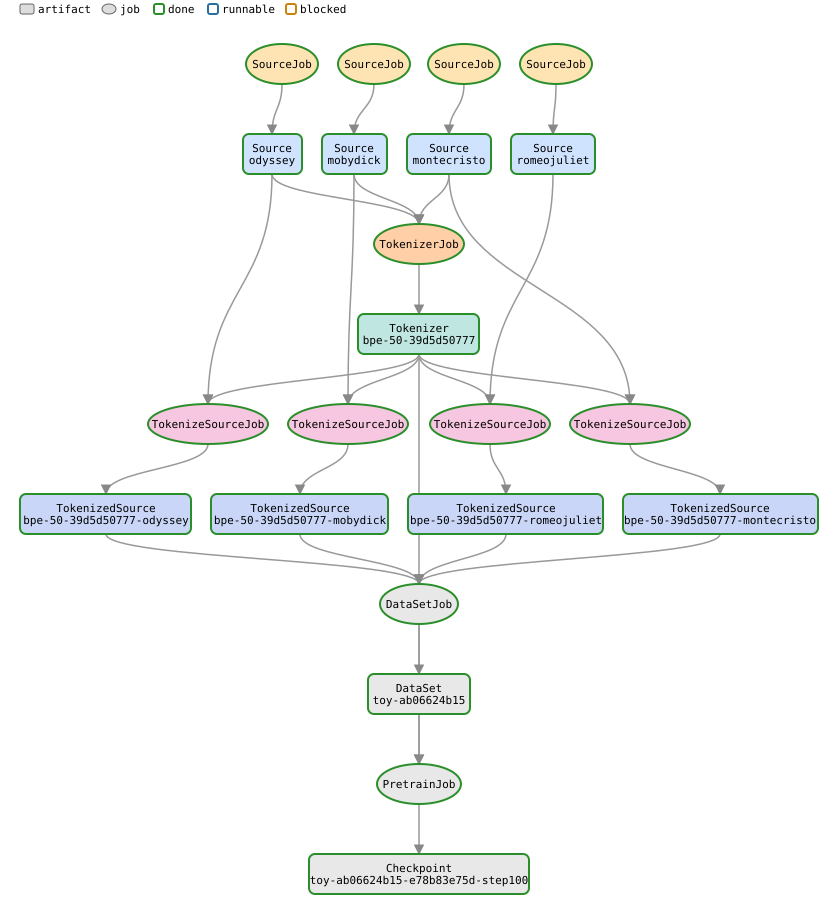

In [4]:
visualize(manifest, root)  # all green now

In [5]:
run_all(checkpoint, root)

skip  odyssey/body.txt  (already done)
skip  mobydick/body.txt  (already done)
skip  montecristo/body.txt  (already done)
skip  tokenizers/bpe-50-39d5d50777/tokenizer.json  (already done)
skip  tokenizers/bpe-50-39d5d50777/bin/odyssey.bin  (already done)
skip  tokenizers/bpe-50-39d5d50777/bin/mobydick.bin  (already done)
skip  romeojuliet/body.txt  (already done)
skip  tokenizers/bpe-50-39d5d50777/bin/romeojuliet.bin  (already done)
skip  tokenizers/bpe-50-39d5d50777/bin/montecristo.bin  (already done)
skip  datasets/toy-ab06624b15/train.bin, datasets/toy-ab06624b15/valid.bin  (already done)
skip  checkpoints/toy-ab06624b15-e78b83e75d-step100/checkpoint.json  (already done)


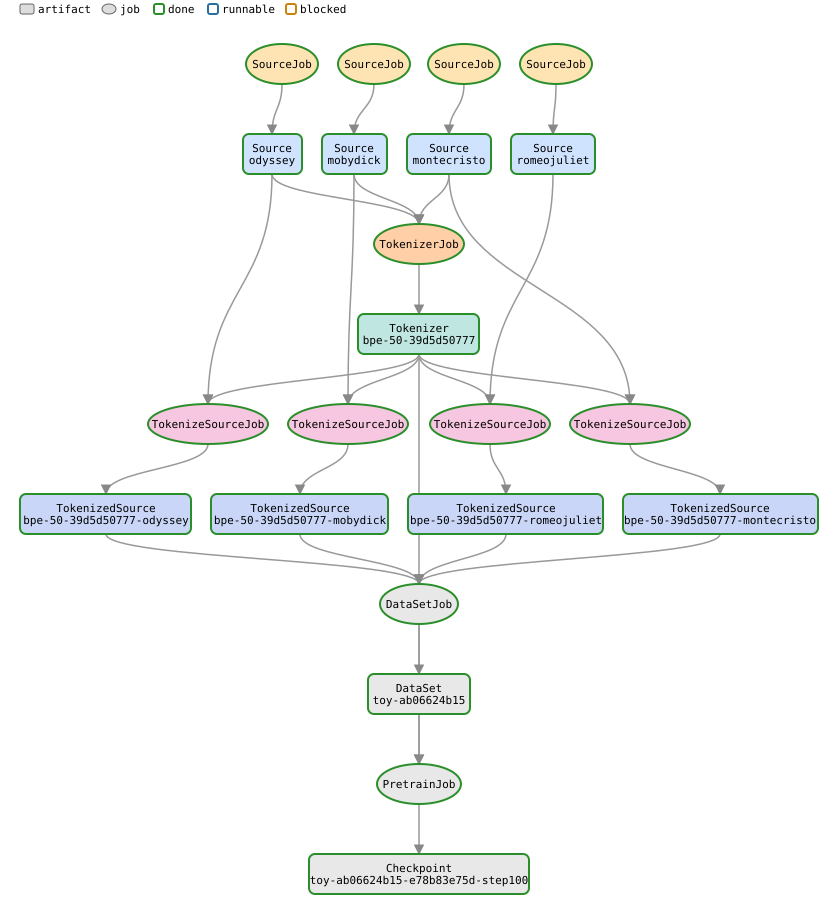

In [6]:
visualize(manifest, root)  # all gree/n now

In [7]:
manifest

{'artifact': Checkpoint(dataset=DataSet(name='toy', train_set=(TokenizedSource(tokenizer=Tokenizer(vocab_size=50, special_tokens=('<pad>', '<unk>'), sources=(Source(name='odyssey', url='https://www.gutenberg.org/cache/epub/1727/pg1727.txt'), Source(name='mobydick', url='https://www.gutenberg.org/cache/epub/2701/pg2701.txt'), Source(name='montecristo', url='https://www.gutenberg.org/cache/epub/1184/pg1184.txt')), kind='bpe'), source=Source(name='odyssey', url='https://www.gutenberg.org/cache/epub/1727/pg1727.txt')), TokenizedSource(tokenizer=Tokenizer(vocab_size=50, special_tokens=('<pad>', '<unk>'), sources=(Source(name='odyssey', url='https://www.gutenberg.org/cache/epub/1727/pg1727.txt'), Source(name='mobydick', url='https://www.gutenberg.org/cache/epub/2701/pg2701.txt'), Source(name='montecristo', url='https://www.gutenberg.org/cache/epub/1184/pg1184.txt')), kind='bpe'), source=Source(name='mobydick', url='https://www.gutenberg.org/cache/epub/2701/pg2701.txt'))), valid_set=(Tokenize